Install PyNNCML From pip
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
pynncml version: 0.3.7
✓ OpenMRG_Sweden folder found at: C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden
✓ Data file (cml.nc) found in local dataset folder
  Note: PyNNCML uses its default location: C:\Users\after\FieldSense\projects\SY_Data_Driven\data\OpenMRG.zip
  The local dataset at C:\Users\after\FieldSense\dataset\open_datasets\OpenMRG_Sweden will not be used automatically
File already exists at desired location ./data/OpenMRG.zip
Not downloading!


100%|████████████████████████████████████████████████████████████████████████████████| 728/728 [05:31<00:00,  2.19it/s]


(data_path='./data/', change2min_max=False, xy_min=None, xy_max=None, time_slice=None, link2gauge_distance=2000, window_size_in_min=15, multiple_gauges_per_link=False, link_selection: pynncml.datasets.xarray_processing.LinkSelection = <LinkSelection.GAUGEONLY: 1>)


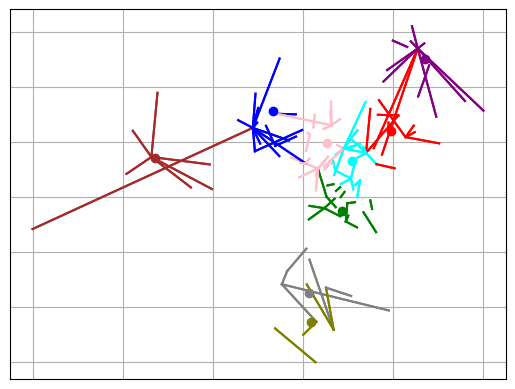

In [1]:
import sys
import os

if os.path.exists('C:/Users/after/FieldSense/core/scientific_packages/pynncml'):
    print("Import PyNNCML From Code")
    import sys, os
    FIELDSENSE_ROOT = r"C:\Users\after\FieldSense"  
    if FIELDSENSE_ROOT not in sys.path:
        sys.path.insert(0, FIELDSENSE_ROOT)
else:
    print("Install PyNNCML From pip")
    %pip install pynncml

import numpy as np
import inspect
import pynncml as pnc  # type: ignore
print("pynncml version:", getattr(pnc, "__version__", "unknown"))
import torch
import math
from matplotlib import pyplot as plt
from tqdm import tqdm
import scipy
from sklearn import metrics

#  @title Hyper-parameters
batch_size = 16  # @param{type:"integer"}
window_size = 32  # @param{type:"integer"}
rnn_n_features = 128  # @param{type:"integer"}
metadata_n_features = 32  # @param{type:"integer"}
n_layers = 2  # @param{type:"integer"}
lr = 1e-4  # @param{type:"number"}
weight_decay = 1e-4  # @param{type:"number"}
rnn_type = pnc.neural_networks.RNNType.GRU  # RNN Type
n_epochs = 200  # @param{type:"integer"}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


time_slice = slice("2015-06-01", "2015-07-10")  # Time Interval

# Check if local OpenMRG dataset exists in FieldSense dataset folder
openmrg_folder = os.path.join("..", "..", "dataset", "open_datasets", "OpenMRG_Sweden")
openmrg_cml_nc = os.path.join(openmrg_folder, "cml", "cml_metadata.csv")

# PyNNCML's default location (where it downloads/looks for data)
pynncml_default_location = os.path.abspath(os.path.join(".", "data", "OpenMRG.zip"))

if os.path.exists(openmrg_folder):
    print(f"✓ OpenMRG_Sweden folder found at: {os.path.abspath(openmrg_folder)}")
    if os.path.exists(openmrg_cml_nc):
        print(f"✓ Data file (cml.nc) found in local dataset folder")
        print(f"  Note: PyNNCML uses its default location: {pynncml_default_location}")
        print(f"  The local dataset at {os.path.abspath(openmrg_folder)} will not be used automatically")
    else:
        print(f"⚠ Data file (cml.nc) NOT found in: {os.path.abspath(openmrg_cml_nc)}")
        print(f"  PyNNCML will use/download data from: {pynncml_default_location}")
else:
    print(f"⚠ OpenMRG_Sweden folder not found at: {os.path.abspath(openmrg_folder)}")
    print(f"  PyNNCML will use/download data from: {pynncml_default_location}")

dataset = pnc.datasets.loader_open_mrg_dataset(time_slice=time_slice)
print(inspect.signature(pnc.datasets.loader_open_mrg_dataset))

#plot links and gages

dataset.link_set.plot_links(scale=True, scale_factor=1.0)
plt.grid()
plt.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)
plt.show()

Rain Rate Statistics
Mean[mm/hr]: 0.10113861569949811
Std[mm/hr]: 0.6187717133949918
Parentage of wet samples 8.323200741126744
Parentage of dry samples 91.67679925887326
Exponential Distribution Parameters: (0.0, 0.10113861569949811)


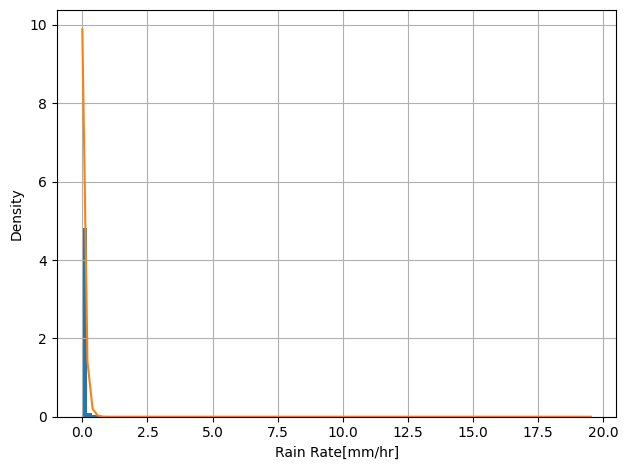

In [2]:
# compute Rain Statistics
rg = np.stack([p.data_array for p in dataset.point_set]).flatten()
param = scipy.stats.expon.fit(rg)
exp_gamma = param[1]
print("Rain Rate Statistics")
print("Mean[mm/hr]:", np.mean(rg))
print("Std[mm/hr]:", np.std(rg))
print("Parentage of wet samples", 100 * np.sum(rg > 0) / rg.size)
print("Parentage of dry samples", 100 * np.sum(rg == 0) / rg.size)
print("Exponential Distribution Parameters:", param)
_ = plt.hist(rg, bins=100, density=True)
plt.plot(np.linspace(0, np.max(rg), 100), scipy.stats.expon.pdf(np.linspace(0, np.max(rg), 100), *param))
plt.grid()
plt.xlabel("Rain Rate[mm/hr]")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [17]:
n_epochs = 200  # @param{type:"integer"}
rnn_n_features = 128  # @param{type:"integer"}
training_dataset, validation_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])
data_loader = torch.utils.data.DataLoader(training_dataset, batch_size)
val_loader = torch.utils.data.DataLoader(validation_dataset, batch_size)
model = pnc.scm.rain_estimation.two_step_network(n_layers=n_layers,  # Number of RNN layers
                                                 rnn_type=rnn_type,  # Type of RNN (GRU, LSTM)
                                                 normalization_cfg=pnc.training_helpers.compute_data_normalization(
                                                     data_loader),
                                                 # Compute the normalization statistics from the training dataset.
                                                 rnn_input_size=180,  # 90 + 90 (RSL + TSL)
                                                 rnn_n_features=rnn_n_features,  # Number of features in the RNN
                                                 metadata_input_size=2,  # Number of metadata features
                                                 metadata_n_features=metadata_n_features,
                                                 # Number of features in the metadata
                                                 pretrained=False).to(
    device)  # Pretrained model is set to False to train the model from scratch.

class RegressionLoss(torch.nn.Module):
    def __init__(self, in_gamma, gamma_s=0.9):
        super(RegressionLoss, self).__init__()
        self.in_gamma = in_gamma
        self.gamma_s = gamma_s

    def forward(self, input, target):
        delta = (target - input) ** 2
        w = 1 - self.gamma_s * torch.exp(-self.in_gamma * target)
        return torch.sum(torch.mean(w * delta, dim=0))


loss_function_rain_est = RegressionLoss(exp_gamma)
loss_function_wet_dry = torch.nn.BCELoss()

# Find lambda values such that at initialization both loss will be equal:
loss_est = 0
loss_detection = 0
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in data_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = (math.floor(rain_rate.shape[1] / window_size))-1
        for step in range(m_step):
            _rr_future = rain_rate[:, step * window_size + 1:(step + 1) * window_size + 1,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_hat = rain_estimation_detection[:, :, 0]
            rain_detection = rain_estimation_detection[:, :, 1]
            loss_est += loss_function_rain_est(rain_hat, _rr_future)
            loss_detection += loss_function_wet_dry(rain_detection, (_rr_future > 0.1).float())
lambda_value = loss_detection / loss_est

In [19]:
# Check if trained model exists and load it
model_path = os.path.abspath("forecast_ws32_lr0.0001_rnn128.pth")

# ALWAYS declare am so later cells can use it
am = pnc.metrics.AverageMetric()

if os.path.exists(model_path):
    print(f"Loading trained model from {model_path}")
    ckpt = torch.load(model_path, map_location=device, weights_only=False)

    # Backward-compatible: allow older files that saved only state_dict
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])

        # Recreate ra so the plotting cell works after loading
        ra = pnc.metrics.ResultsAccumulator()
        loss_hist = ckpt.get("loss_history", {})
        for l, le, ld in zip(
            loss_hist.get("loss", []),
            loss_hist.get("loss_est", []),
            loss_hist.get("loss_detection", []),
        ):
            ra.add_results(loss=l, loss_est=le, loss_detection=ld)

        # Optional: restore last-epoch snapshot into am (for inspection only)
        am_snapshot = ckpt.get("am_snapshot", None)
        if am_snapshot is not None:
            last = am_snapshot.get("last_epoch", {})
            am.clear()
            if last:
                am.add_results(
                    loss=last.get("loss", 0.0),
                    loss_est=last.get("loss_est", 0.0),
                    loss_detection=last.get("loss_detection", 0.0),
                )

    else:
        # Older weights-only file
        model.load_state_dict(ckpt)
        ra = pnc.metrics.ResultsAccumulator()
        am.clear()

    print(f"Loaded trained model from {model_path}")
    model.eval()  # Set to evaluation mode
    print("Model loaded. Skipping training.")

else:
    print(f"Model file not found at {model_path}. Starting training...")

    opt = torch.optim.RAdam(model.parameters(), lr=lr, weight_decay=weight_decay)
    ra = pnc.metrics.ResultsAccumulator()
    am = pnc.metrics.AverageMetric()  # already declared, but explicit here is fine

    model.train()
    print("Start Training")

    for epoch in tqdm(range(n_epochs)):
        am.clear()

        for rain_rate, rsl, tsl, metadata in data_loader:
            state = model.init_state(batch_size=rsl.shape[0])
            m_step = math.floor(rain_rate.shape[1] / window_size)

            for step in range(m_step):
                opt.zero_grad()

                _rr_future = rain_rate[
                    :, step * window_size+1 : (step + 1) * window_size+1, 0
                ].float().to(device)
                _rsl = rsl[
                    :, step * window_size : (step + 1) * window_size, :
                ].to(device)
                _tsl = tsl[
                    :, step * window_size : (step + 1) * window_size, :
                ].to(device)

                rain_estimation_detection, state = model(
                    torch.cat([_rsl, _tsl], dim=-1),
                    metadata.to(device),
                    state.detach(),
                )

                rain_hat = rain_estimation_detection[:, :, 0]
                rain_detection = rain_estimation_detection[:, :, 1]

                loss_est = loss_function_rain_est(rain_hat, _rr_future)
                loss_detection = loss_function_wet_dry(
                    rain_detection, (_rr_future > 0.1).float()
                )
                loss = lambda_value * loss_est + loss_detection

                loss.backward()
                opt.step()

                am.add_results(
                    loss=loss.item(),
                    loss_est=loss_est.item(),
                    loss_detection=loss_detection.item(),
                )

        ra.add_results(
            loss=am.get_results("loss"),
            loss_est=am.get_results("loss_est"),
            loss_detection=am.get_results("loss_detection"),
        )

    # ---- Save checkpoint ----
    loss_history = {
        "loss": list(ra.get_results("loss")),
        "loss_est": list(ra.get_results("loss_est")),
        "loss_detection": list(ra.get_results("loss_detection")),
    }

    am_snapshot = {
        "last_epoch": {
            "loss": am.get_results("loss"),
            "loss_est": am.get_results("loss_est"),
            "loss_detection": am.get_results("loss_detection"),
        }
    }

    ckpt = {
        "model_state_dict": model.state_dict(),
        "loss_history": loss_history,
        "am_snapshot": am_snapshot,
        "hyperparams": {
            "lr": lr,
            "weight_decay": weight_decay,
            "lambda_value": lambda_value,
            "window_size": window_size,
            "n_epochs": n_epochs,
        },
    }

    torch.save(ckpt, model_path)
    print("Model saved successfully!")



Loading trained model from C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0001_rnn128.pth
Loaded trained model from C:\Users\after\FieldSense\projects\SY_Data_Driven\forecast_ws32_lr0.0001_rnn128.pth
Model loaded. Skipping training.


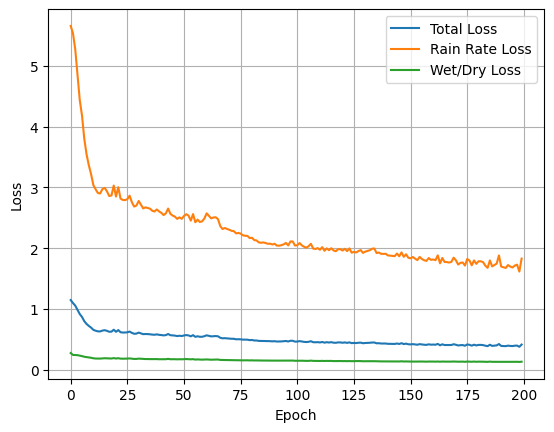

In [20]:
plt.plot(ra.get_results("loss"), label="Total Loss")
plt.plot(ra.get_results("loss_est"), label="Rain Rate Loss")
plt.plot(ra.get_results("loss_detection"), label="Wet/Dry Loss")
plt.grid()
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Results Detection:
Validation Results of Two-Step RNN
Accuracy[%]: 95.82097457627118
F1 Score: 0.6437923250564334


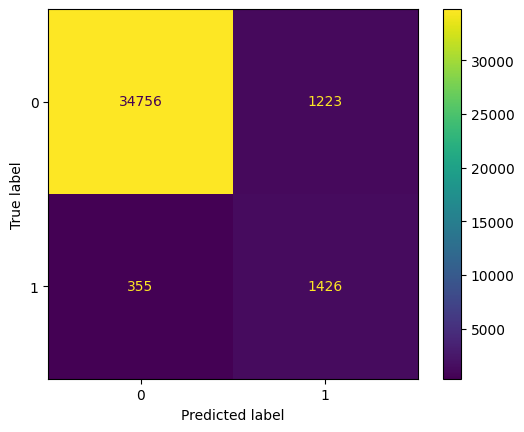

Results Estimation:
-------------------------------------------------- Results Summery --------------------------------------------------
+--------------+--------------------------+----------------------------------------+----------------------------------------+-----------------------------------------+-----------------------------------------+
|    Metric    | 0.0<r<3.9000000953674316 | 3.9000000953674316<r<7.809999942779541 | 7.809999942779541<r<11.710000038146973 | 11.710000038146973<r<15.619999885559082 | 15.619999885559082<r<19.520000457763672 |
+--------------+--------------------------+----------------------------------------+----------------------------------------+-----------------------------------------+-----------------------------------------+
|     RMSE     |           0.33           |                  2.18                  |                  4.54                  |                   8.48                  |                   9.12                  |
|     BIAS     |      

In [21]:
model.eval()
ga = pnc.metrics.GroupAnalysis()
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in val_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = (math.floor(rain_rate.shape[1] / window_size))-1
        am.clear()
        rain_ref_list = []
        rain_hat_list = []
        detection_list = []

        for step in range(m_step):
            _rr_future = rain_rate[:, step * window_size + 1:(step + 1) * window_size + 1,0].float().to(device)
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            rain_estimation_detection, state = model(torch.cat([_rsl, _tsl], dim=-1), metadata.to(device),
                                                     state.detach())
            rain_detection = rain_estimation_detection[:, :, 1]
            rain_hat = rain_estimation_detection[:, :, 0] * torch.round(
                rain_detection)  # Rain Rate is computed only for wet samples
            rain_hat_list.append(rain_hat.detach().cpu().numpy())
            rain_ref_list.append(_rr_future.detach().cpu().numpy())
            ga.append(rain_ref_list[-1], rain_hat_list[-1])
            detection_list.append(torch.round(rain_detection).detach().cpu().numpy())
            delta = rain_hat.squeeze(dim=-1) - _rr_future
            bias = torch.mean(delta)
            mse = torch.mean(delta ** 2)
            am.add_results(bias=bias.item(), mse=mse.item())
actual = np.concatenate(detection_list).flatten()
predicted = (np.concatenate(rain_ref_list) > 0.1).astype("float").flatten()
confusion_matrix = metrics.confusion_matrix(actual, predicted)
max_rain = np.max(np.concatenate(rain_ref_list))
g_array = np.linspace(0, max_rain, 6)

print("Results Detection:")
print("Validation Results of Two-Step RNN")
print("Accuracy[%]:", 100 * (np.sum(actual == predicted) / actual.size))
print("F1 Score:", metrics.f1_score(actual, predicted))

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=[0, 1])

cm_display.plot()
plt.show()

print("Results Estimation:")
_ = ga.run_analysis(np.stack([g_array[:-1], g_array[1:]], axis=-1))


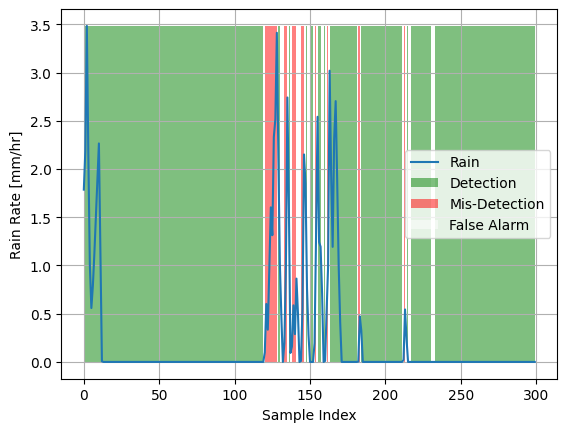

In [22]:
detection_array = np.concatenate(detection_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)
detection_array = np.round(detection_array)

rain_array = rain_ref_array[0, :300]
detection_array = detection_array[0, :300]
fig, ax = plt.subplots()
x = np.arange(rain_array.shape[0])
ax.plot(x, rain_array, label="Rain")
rain_max = np.max(rain_array)
ax.fill_between(x, rain_max, where=np.logical_or(np.logical_and(detection_array == 1, rain_array > 0),
                                                 np.logical_and(detection_array == 0, rain_array == 0)),
                facecolor='green', alpha=.5, label="Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 0, rain_array > 0), facecolor='red',
                alpha=.5, label="Mis-Detection")
ax.fill_between(x, rain_max, where=np.logical_and(detection_array == 1, rain_array <=0.1), facecolor='white',
                alpha=.5, label="False Alarm")
plt.legend()
plt.ylabel("Rain Rate [mm/hr]")
plt.xlabel("Sample Index")
plt.grid()
plt.show()

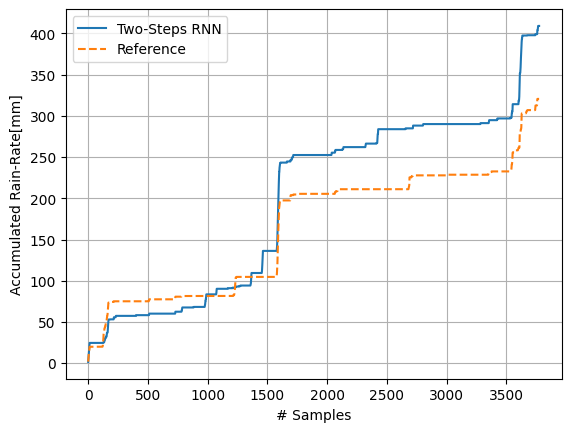

In [23]:
rain_hat_array = np.concatenate(rain_hat_list, axis=1)
rain_ref_array = np.concatenate(rain_ref_list, axis=1)

plt.plot(np.cumsum(np.maximum(rain_hat_array[0, :], 0)), label="Two-Steps RNN")
plt.plot(np.cumsum(rain_ref_array[0, :]), "--", label="Reference")
plt.grid()
plt.legend()
plt.ylabel("Accumulated Rain-Rate[mm]")
plt.xlabel("# Samples")
plt.show()

In [28]:
# 1. איסוף כל התחזיות מהמודל בצורה מסודרת
all_link_preds = []
model.eval()

print("Aggregating predictions for mapping...")
with torch.no_grad():
    for rain_rate, rsl, tsl, metadata in data_loader:
        state = model.init_state(batch_size=rsl.shape[0])
        m_step = math.floor(rain_rate.shape[1] / window_size)
        
        batch_time_preds = []
        for step in range(m_step):
            _rsl = rsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            _tsl = tsl[:, step * window_size:(step + 1) * window_size, :].to(device)
            
            rain_estimation_detection, state = model(
                torch.cat([_rsl, _tsl], dim=-1), 
                metadata.to(device), 
                state.detach()
            )
            
            rain_hat = rain_estimation_detection[:, :, 0]
            rain_detection = rain_estimation_detection[:, :, 1]
            rain_hat = rain_hat * torch.round(rain_detection)
            
            batch_time_preds.append(rain_hat.cpu())
        
        if batch_time_preds:
            link_batch_full_time = torch.cat(batch_time_preds, dim=1)
            all_link_preds.append(link_batch_full_time)

if all_link_preds:
    res_ml = torch.cat(all_link_preds, dim=0)
    print(f"Predictions shape: {res_ml.shape}") 

    # ---------------------------------------------------------
    # תיקון סופי: יצירת אובייקט LinkSet חדש עבור תת-הקבוצה
    # ---------------------------------------------------------
    
    # 1. גישה ל-dataset המקורי כדי לחלץ את הלינקים
    full_dataset = data_loader.dataset.dataset if hasattr(data_loader.dataset, 'dataset') else data_loader.dataset
    
    # חילוץ רשימת הלינקים הגולמית
    if hasattr(full_dataset.link_set, 'link_list'):
        full_link_list = full_dataset.link_set.link_list
    else:
        # ניסיון המרה ישיר אם המאפיין לא קיים
        full_link_list = list(full_dataset.link_set)

    # 2. סינון הלינקים לפי ה-indices של ה-Validation Set
    if hasattr(data_loader.dataset, 'indices'):
        indices = data_loader.dataset.indices
        print(f"Filtering links to match validation set ({len(indices)} links).")
        current_link_list = [full_link_list[i] for i in indices]
    else:
        current_link_list = full_link_list[:res_ml.shape[0]]

    # 3. יצירת אובייקט LinkSet חדש!
    # אנו לוקחים את ה'סוג' (Class) של האובייקט המקורי ויוצרים מופע חדש עם הרשימה שלנו.
    # זה גורם לחישוב מחדש של x_delta, y_delta עבור הרשימה הקטנה יותר.
    LinkSetClass = type(full_dataset.link_set)
    try:
        subset_link_set = LinkSetClass(current_link_list)
        print(f"Created new LinkSet with {len(subset_link_set)} links.")
    except Exception as e:
        # במקרה של שגיאה בבנאי, ננסה להעתיק ולערוך
        print(f"Direct init failed ({e}), trying copy method...")
        subset_link_set = copy.copy(full_dataset.link_set)
        subset_link_set.link_list = current_link_list
        # אנו מקווים שהפונקציה idw תסתדר או שתחשב מחדש את הגבולות,
        # אך לרוב הבנאי למעלה הוא הדרך הנכונה.

    # 2. הגדרת פרמטרים וביצוע אינטרפולציה
    region_of_interest = 3
    
    try:
        # כעת אנו מעבירים אובייקט LinkSet תקין ולא רשימה
        idw = pnc.mcm.generate_link_set_idw(subset_link_set, roi=region_of_interest)
        
        rain_map = idw(res_ml).numpy()
        print("Rain map generated successfully.")
        
        # 3. הצגת המפה
        spatial_sum = np.sum(rain_map, axis=(1, 2))
        index = np.argmax(spatial_sum)
        
        peak_rain = np.max(rain_map)
        if peak_rain == 0: peak_rain = 1.0
        
        bounds = np.arange(0, peak_rain, peak_rain / 10)
        if len(bounds) > 0: bounds[0] = 0.01
        else: bounds = np.linspace(0, 1, 10)

        norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')

        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        
        pc = ax.pcolormesh(
            idw.x_grid_vector,
            idw.y_grid_vector,
            rain_map[index, :, :].T,
            shading='nearest',
            cmap='turbo',
            norm=norm,
        )
        
        ax.set_title(f'Neural Network Rain Prediction (IDW)\nTime Index: {index}')
        ax.set_aspect('equal', 'box')
        fig.colorbar(pc, label='Rainfall in mm/h')
        
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error during IDW generation: {e}")
        import traceback
        traceback.print_exc()

else:
    print("No predictions were generated.")

Aggregating predictions for mapping...
Predictions shape: torch.Size([172, 3808])
Filtering links to match validation set (172 links).
Created new LinkSet with 172 links.
Rain map generated successfully.
Error during IDW generation: name 'mpl' is not defined


Traceback (most recent call last):
  File "C:\Users\after\AppData\Local\Temp\ipykernel_30648\291630531.py", line 94, in <module>
    norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='both')
           ^^^
NameError: name 'mpl' is not defined
